# A/B Testing Analysis: Urgency Nudge on E-commerce Checkout Flow

**Business Scenario:**  
Does adding an urgency nudge (*"Only 3 left in stock!"*) on the product page increase purchase conversion — and at what cost?


## 0. Setup

In this section, we load the required libraries, configure our premium visualization styling, and load the experiment dataset.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest, proportion_confint, proportion_effectsize
from statsmodels.stats.power import NormalIndPower
from IPython.display import display, Markdown

# Set style for premium visualizations
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'font.family': 'sans-serif',
    'figure.facecolor': '#f8f9fa',
    'axes.facecolor': '#ffffff'
})

# Custom premium palette
colors = {
    'control': '#6c757d',      # Slate gray
    'treatment': '#007bff',    # Deep premium blue
    'desktop': '#17a2b8',      # Teal
    'mobile': '#e83e8c',       # Vibrant Pink
    'highlight': '#fd7e14'     # Coral
}

# Load the dataset
df = pd.read_csv('ab_test_data.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("--- Dataset Summary ---")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n--- Sample Rows ---")
display(df.head())
print("\n--- General Info ---")
df.info()

--- Dataset Summary ---
Shape: 10000 rows, 8 columns

--- Sample Rows ---


,user_id,timestamp,group,device,user_type,converted,returned,session_duration
0,USR_06253,2026-06-08 14:31:19,treatment,mobile,new,0,0,200.4
1,USR_04685,2026-06-08 17:06:05,control,desktop,new,0,0,237.0
2,USR_01732,2026-06-09 17:13:16,control,mobile,new,0,0,82.9
3,USR_04743,2026-06-11 18:47:34,control,desktop,new,0,0,42.0
4,USR_04522,2026-06-18 19:29:43,control,desktop,new,0,0,91.9



--- General Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           10000 non-null  object        
 1   timestamp         10000 non-null  datetime64[ns]
 2   group             10000 non-null  object        
 3   device            10000 non-null  object        
 4   user_type         10000 non-null  object        
 5   converted         10000 non-null  int64         
 6   returned          10000 non-null  int64         
 7   session_duration  10000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 625.1+ KB


## 1. Experiment Design

Before launching an experiment, it is critical to determine the required sample size based on statistical power. This prevents running an underpowered test (which fails to detect real effects) or wastefully running the test too long.

### Experiment Design Parameters:
- **Baseline Conversion Rate ($p_1$):** 9.88% (rounded to 10% for baseline planning)
- **Minimum Detectable Effect (MDE):** 2.0% absolute lift (targeting 12.0% in Treatment)
- **Significance Level ($\alpha$):** 5% (two-tailed)
- **Power ($1 - \beta$):** 80%

In [2]:
# Planning parameters
p1 = 0.0988
p2 = 0.12  # baseline + MDE
alpha = 0.05
power = 0.80

# Compute standard effect size (Cohen's h)
effect_size = proportion_effectsize(p1, p2)

# Solve for required sample size per group
power_analysis = NormalIndPower()
required_n = power_analysis.solve_power(
    effect_size=effect_size, 
    alpha=alpha, 
    power=power, 
    ratio=1.0, 
    alternative='two-sided'
)

print(f"Required sample size per group (for MDE=2%): {round(required_n):,} users")
print(f"Actual sample size per group: {df[df['group'] == 'control'].shape[0]:,} users")

# Post-hoc power of our study given actual sample sizes and observed conversion rates
obs_p1 = df[df['group'] == 'control']['converted'].mean()
obs_p2 = df[df['group'] == 'treatment']['converted'].mean()
n_ctrl = df[df['group'] == 'control'].shape[0]

obs_effect_size = proportion_effectsize(obs_p1, obs_p2)
achieved_power = power_analysis.solve_power(
    effect_size=obs_effect_size,
    nobs1=n_ctrl,
    alpha=alpha,
    ratio=1.0,
    alternative='two-sided'
)
print(f"Post-hoc power achieved for observed lift ({obs_p1*100:.2f}% -> {obs_p2*100:.2f}%): {achieved_power*100:.2f}%")

Required sample size per group (for MDE=2%): 3,396 users
Actual sample size per group: 5,000 users
Post-hoc power achieved for observed lift (9.88% -> 12.18%): 95.69%


## 2. EDA & Sanity Checks

We conduct data quality checks and run a **Sample Ratio Mismatch (SRM)** check to confirm that users were randomly assigned to groups in the expected 50/50 proportion.

--- Sample Ratio Mismatch (SRM) Check ---
Observed Control size: 5,000 (50.00%)
Observed Treatment size: 5,000 (50.00%)
Chi-square statistic: 0.0000
SRM Check p-value: 1.0000
SRM Check Passed: No evidence of assignment bias.

--- Data Integrity Checks ---
Total Nulls in dataset:
user_id             0
timestamp           0
group               0
device              0
user_type           0
converted           0
returned            0
session_duration    0
dtype: int64
Duplicate User IDs: 0


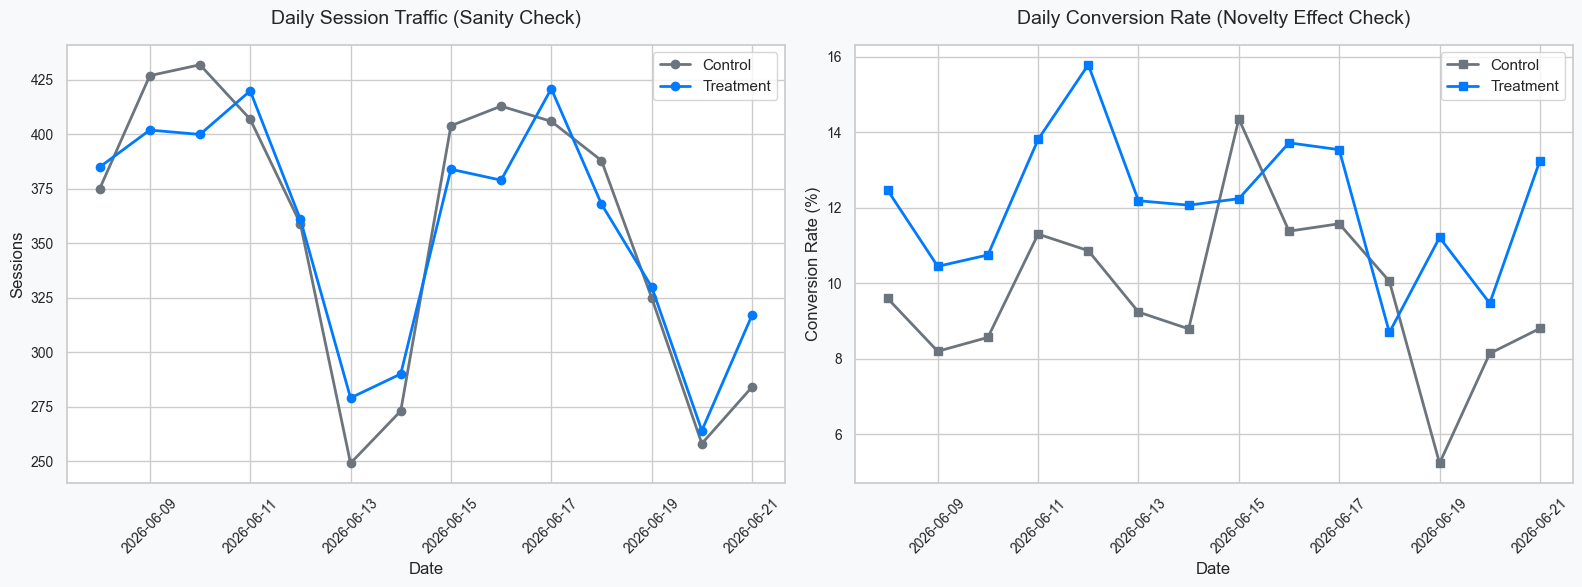

In [3]:
# 1. SRM Check using Chi-Square Goodness-of-Fit
obs_control = df[df['group'] == 'control'].shape[0]
obs_treatment = df[df['group'] == 'treatment'].shape[0]
n_total = len(df)
expected_control = n_total / 2
expected_treatment = n_total / 2

chi2_stat, p_srm = stats.chisquare(f_obs=[obs_control, obs_treatment], f_exp=[expected_control, expected_treatment])

print("--- Sample Ratio Mismatch (SRM) Check ---")
print(f"Observed Control size: {obs_control:,} ({obs_control/n_total*100:.2f}%)")
print(f"Observed Treatment size: {obs_treatment:,} ({obs_treatment/n_total*100:.2f}%)")
print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"SRM Check p-value: {p_srm:.4f}")
if p_srm < 0.001:
    print("CRITICAL: SRM Detected! Randomizer is compromised.")
else:
    print("SRM Check Passed: No evidence of assignment bias.")

# 2. Missing Value and Duplicate Check
print("\n--- Data Integrity Checks ---")
print(f"Total Nulls in dataset:\n{df.isnull().sum()}")
print(f"Duplicate User IDs: {df['user_id'].duplicated().sum()}")

# Create date column for daily analysis
df['date'] = df['timestamp'].dt.date

# Compute daily aggregated stats
daily_stats = df.groupby(['date', 'group']).agg(
    sessions=('user_id', 'count'),
    conversions=('converted', 'sum')
).reset_index()
daily_stats['cr'] = daily_stats['conversions'] / daily_stats['sessions']

# 3 & 4. Visualizations: Daily Traffic and Daily CR (Novelty Effect)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Daily traffic
for grp, col in [('control', colors['control']), ('treatment', colors['treatment'])]:
    subset = daily_stats[daily_stats['group'] == grp]
    axes[0].plot(subset['date'], subset['sessions'], marker='o', label=grp.capitalize(), color=col, linewidth=2)
axes[0].set_title('Daily Session Traffic (Sanity Check)', pad=15)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sessions')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# Daily conversion rate (novelty check)
for grp, col in [('control', colors['control']), ('treatment', colors['treatment'])]:
    subset = daily_stats[daily_stats['group'] == grp]
    axes[1].plot(subset['date'], subset['cr'] * 100, marker='s', label=grp.capitalize(), color=col, linewidth=2)
axes[1].set_title('Daily Conversion Rate (Novelty Effect Check)', pad=15)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Core Analysis

In this section, we analyze the overall conversion rates of Control and Treatment. We run a two-proportion z-test, compute confidence intervals, compute Cohen's h, and perform a vectorized bootstrap simulation to visualize the conversion rate difference.

--- Overall Performance ---
Control Conversion Rate: 494/5000 (9.88%)
Treatment Conversion Rate: 609/5000 (12.18%)
Absolute Lift: +2.30%
Relative Lift: +23.28%

--- Hypothesis Testing ---
Z-statistic: 3.6710
P-value: 2.4157e-04 (Significant)
95% Confidence Interval for Difference: [1.07%, 3.53%]
Cohen's h: 0.0735 (small effect)


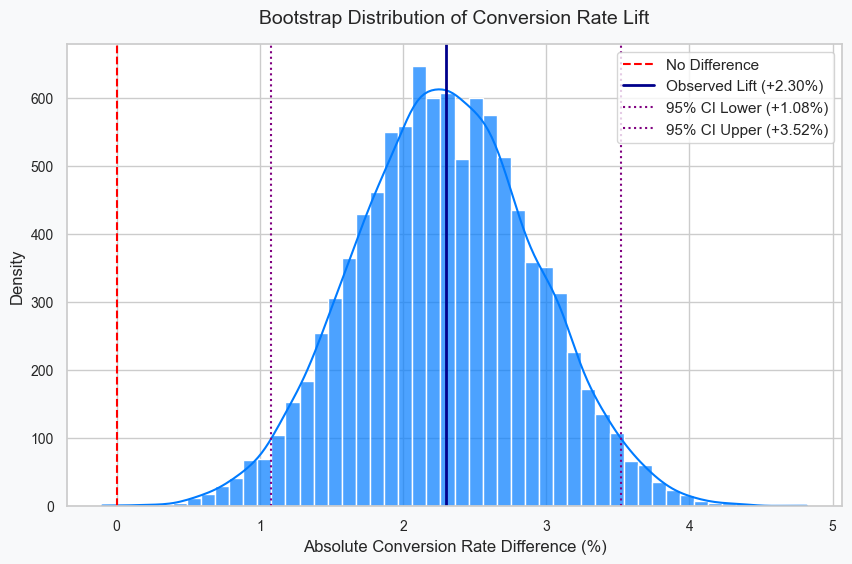

In [4]:
# Raw overall conversions
conv_ctrl = df[df['group'] == 'control']['converted'].sum()
n_ctrl = df[df['group'] == 'control'].shape[0]
cr_ctrl = conv_ctrl / n_ctrl

conv_treat = df[df['group'] == 'treatment']['converted'].sum()
n_treat = df[df['group'] == 'treatment'].shape[0]
cr_treat = conv_treat / n_treat

abs_lift = cr_treat - cr_ctrl
rel_lift = abs_lift / cr_ctrl

print("--- Overall Performance ---")
print(f"Control Conversion Rate: {conv_ctrl}/{n_ctrl} ({cr_ctrl*100:.2f}%)")
print(f"Treatment Conversion Rate: {conv_treat}/{n_treat} ({cr_treat*100:.2f}%)")
print(f"Absolute Lift: {abs_lift*100:+.2f}%")
print(f"Relative Lift: {rel_lift*100:+.2f}%")

# 1 & 2. Two-Proportion Z-test and Confidence Interval of the Difference
z_stat, p_val = proportions_ztest(count=[conv_treat, conv_ctrl], nobs=[n_treat, n_ctrl], alternative='two-sided')

# Standard Error for the difference
se_diff = np.sqrt((cr_treat * (1 - cr_treat) / n_treat) + (cr_ctrl * (1 - cr_ctrl) / n_ctrl))
margin_error = 1.96 * se_diff
ci_low = abs_lift - margin_error
ci_high = abs_lift + margin_error

print("\n--- Hypothesis Testing ---")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_val:.4e} {'(Significant)' if p_val < 0.05 else '(Not Significant)'}")
print(f"95% Confidence Interval for Difference: [{ci_low*100:.2f}%, {ci_high*100:.2f}%]")

# 3. Cohen's h (Effect Size)
h = 2 * (np.arcsin(np.sqrt(cr_treat)) - np.arcsin(np.sqrt(cr_ctrl)))
print(f"Cohen's h: {h:.4f} ({'small' if h < 0.2 else 'medium' if h < 0.5 else 'large'} effect)")

# 4. Vectorized Bootstrap Simulation
n_bootstrap = 10000
control_convs = df[df['group'] == 'control']['converted'].values
treatment_convs = df[df['group'] == 'treatment']['converted'].values

np.random.seed(42)
boot_ctrl = np.random.choice(control_convs, size=(n_bootstrap, len(control_convs)), replace=True).mean(axis=1)
boot_treat = np.random.choice(treatment_convs, size=(n_bootstrap, len(treatment_convs)), replace=True).mean(axis=1)
boot_lifts = (boot_treat - boot_ctrl) * 100

boot_ci_low = np.percentile(boot_lifts, 2.5)
boot_ci_high = np.percentile(boot_lifts, 97.5)

# Plot Bootstrap Lift Distribution
plt.figure(figsize=(10, 6))
sns.histplot(boot_lifts, kde=True, color=colors['treatment'], bins=50, edgecolor='white', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='No Difference')
plt.axvline(abs_lift * 100, color='darkblue', linestyle='-', linewidth=2, label=f'Observed Lift ({abs_lift*100:+.2f}%)')
plt.axvline(boot_ci_low, color='purple', linestyle=':', linewidth=1.5, label=f'95% CI Lower ({boot_ci_low:+.2f}%)')
plt.axvline(boot_ci_high, color='purple', linestyle=':', linewidth=1.5, label=f'95% CI Upper ({boot_ci_high:+.2f}%)')
plt.title('Bootstrap Distribution of Conversion Rate Lift', pad=15)
plt.xlabel('Absolute Conversion Rate Difference (%)')
plt.ylabel('Density')
plt.legend()
plt.show()

## 4. Guardrail Metrics

An increase in conversion rate is only valuable if it doesn't degrade other key performance areas. We evaluate two guardrail metrics:
1. **Return Rate (among converted users):** Did the urgency nudge lead to panic-buying that was returned at a higher rate?
2. **Session Duration:** Did the urgency nudge cause users to rush through pages (lower duration) or cause frustration?

--- Guardrail: Return Rate (Purchasers Only) ---
Control Return Rate: 42/494 (8.50%)
Treatment Return Rate: 70/609 (11.49%)
Absolute Return Rate Increase: +2.99%
Z-test p-value: 0.1018

--- Guardrail: Session Duration ---
Control Mean Duration: 100.35s
Treatment Mean Duration: 104.40s
Welch's t-test p-value: 1.6605e-05


C:\Users\umang\AppData\Local\Temp\ipykernel_15640\2240569829.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Control', 'Treatment'], y=[rr_ctrl*100, rr_treat*100], palette=[colors['control'], colors['treatment']], ax=axes[0])


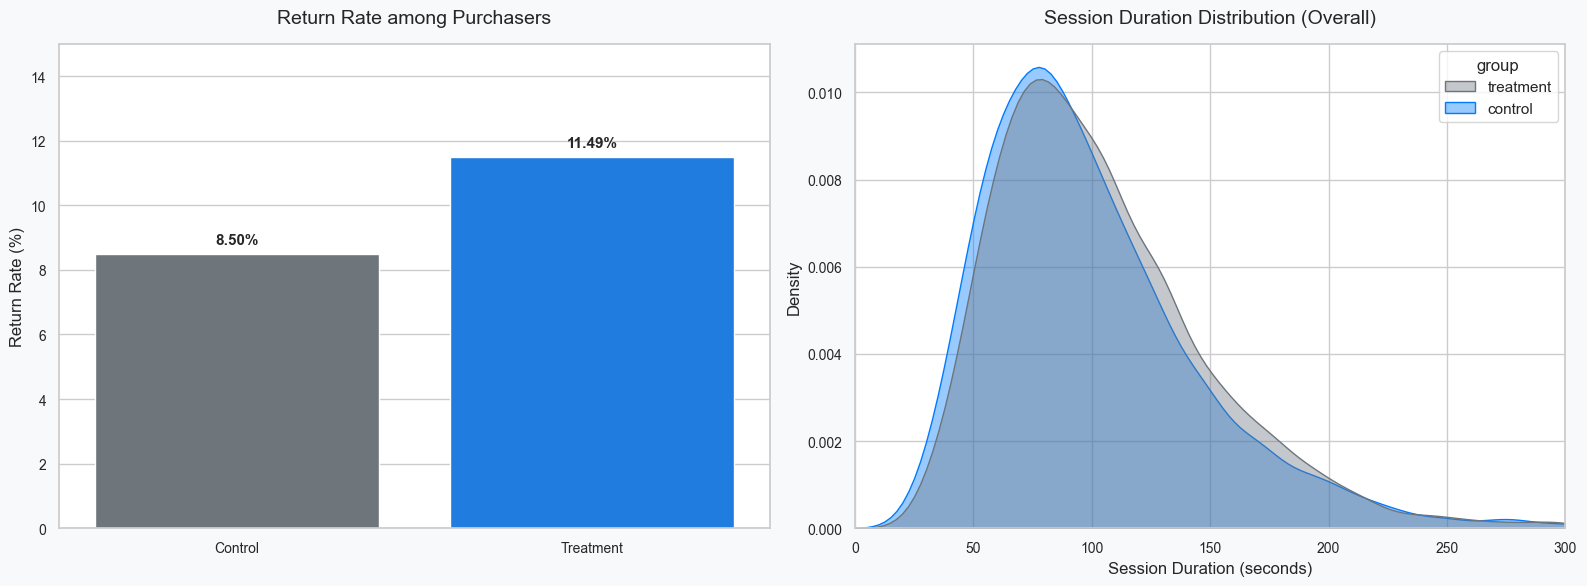

In [5]:
# Filter to purchasers
purchasers = df[df['converted'] == 1]
ret_ctrl = purchasers[purchasers['group'] == 'control']['returned'].sum()
n_ret_ctrl = purchasers[purchasers['group'] == 'control'].shape[0]
rr_ctrl = ret_ctrl / n_ret_ctrl

ret_treat = purchasers[purchasers['group'] == 'treatment']['returned'].sum()
n_ret_treat = purchasers[purchasers['group'] == 'treatment'].shape[0]
rr_treat = ret_treat / n_ret_treat

rr_diff = rr_treat - rr_ctrl

print("--- Guardrail: Return Rate (Purchasers Only) ---")
print(f"Control Return Rate: {ret_ctrl}/{n_ret_ctrl} ({rr_ctrl*100:.2f}%)")
print(f"Treatment Return Rate: {ret_treat}/{n_ret_treat} ({rr_treat*100:.2f}%)")
print(f"Absolute Return Rate Increase: {rr_diff*100:+.2f}%")

# Z-test on returns
z_ret, p_ret = proportions_ztest([ret_treat, ret_ctrl], [n_ret_treat, n_ret_ctrl])
print(f"Z-test p-value: {p_ret:.4f}")

# Welch's t-test on Session Duration
dur_ctrl = df[df['group'] == 'control']['session_duration']
dur_treat = df[df['group'] == 'treatment']['session_duration']

t_stat, p_dur = stats.ttest_ind(dur_treat, dur_ctrl, equal_var=False)

print("\n--- Guardrail: Session Duration ---")
print(f"Control Mean Duration: {dur_ctrl.mean():.2f}s")
print(f"Treatment Mean Duration: {dur_treat.mean():.2f}s")
print(f"Welch's t-test p-value: {p_dur:.4e}")

# Plot Guardrails
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot for return rate
sns.barplot(x=['Control', 'Treatment'], y=[rr_ctrl*100, rr_treat*100], palette=[colors['control'], colors['treatment']], ax=axes[0])
axes[0].set_title('Return Rate among Purchasers', pad=15)
axes[0].set_ylabel('Return Rate (%)')
for i, val in enumerate([rr_ctrl*100, rr_treat*100]):
    axes[0].text(i, val + 0.3, f"{val:.2f}%", ha='center', fontweight='bold')
axes[0].set_ylim(0, 15)

# KDE for Session Duration
sns.kdeplot(data=df, x='session_duration', hue='group', fill=True, palette=[colors['control'], colors['treatment']], common_norm=False, alpha=0.4, ax=axes[1])
axes[1].set_title('Session Duration Distribution (Overall)', pad=15)
axes[1].set_xlabel('Session Duration (seconds)')
axes[1].set_xlim(0, 300) # clip for readability

plt.tight_layout()
plt.show()

## 5. Segmentation

A single overall analysis can mask opposing segment behaviors. Here we drill down and analyze our results segmented by **Device** (Desktop vs. Mobile) and **User Type** (New vs. Returning).

--- Device Segmentation ---

Device: DESKTOP
  Control:   257/2200 (11.68%)
  Treatment: 370/2200 (16.82%)
  Absolute Lift: +5.14%
  P-value: 0.000001 (Significant)

Device: MOBILE
  Control:   237/2800 (8.46%)
  Treatment: 239/2800 (8.54%)
  Absolute Lift: +0.07%
  P-value: 0.923653 (Not Significant)

--- User Type Segmentation ---

User Type: New
  Control:   297/2977 (9.98%)
  Treatment: 368/3002 (12.26%)
  Absolute Lift: +2.28%
  P-value: 0.005014 (Significant)

User Type: Returning
  Control:   197/2023 (9.74%)
  Treatment: 241/1998 (12.06%)
  Absolute Lift: +2.32%
  P-value: 0.018026 (Significant)


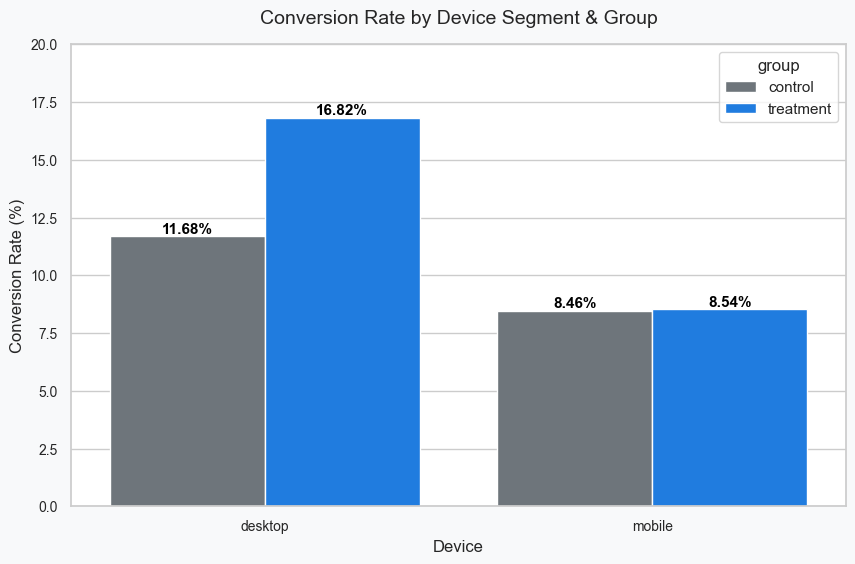

In [6]:
# Segmentation by Device
print("--- Device Segmentation ---")
for dev in ['desktop', 'mobile']:
    sub = df[df['device'] == dev]
    ctrl_sub = sub[sub['group'] == 'control']
    treat_sub = sub[sub['group'] == 'treatment']
    
    conv_ctrl_sub = ctrl_sub['converted'].sum()
    conv_treat_sub = treat_sub['converted'].sum()
    
    cr_c = conv_ctrl_sub / len(ctrl_sub)
    cr_t = conv_treat_sub / len(treat_sub)
    lift_sub = cr_t - cr_c
    
    _, p_sub = proportions_ztest([conv_treat_sub, conv_ctrl_sub], [len(treat_sub), len(ctrl_sub)])
    
    print(f"\nDevice: {dev.upper()}")
    print(f"  Control:   {conv_ctrl_sub}/{len(ctrl_sub)} ({cr_c*100:.2f}%)")
    print(f"  Treatment: {conv_treat_sub}/{len(treat_sub)} ({cr_t*100:.2f}%)")
    print(f"  Absolute Lift: {lift_sub*100:+.2f}%")
    print(f"  P-value: {p_sub:.6f} {'(Significant)' if p_sub < 0.05 else '(Not Significant)'}")

# Segmentation by User Type
print("\n--- User Type Segmentation ---")
for utype in ['new', 'returning']:
    sub = df[df['user_type'] == utype]
    ctrl_sub = sub[sub['group'] == 'control']
    treat_sub = sub[sub['group'] == 'treatment']
    
    conv_ctrl_sub = ctrl_sub['converted'].sum()
    conv_treat_sub = treat_sub['converted'].sum()
    
    cr_c = conv_ctrl_sub / len(ctrl_sub)
    cr_t = conv_treat_sub / len(treat_sub)
    lift_sub = cr_t - cr_c
    
    _, p_sub = proportions_ztest([conv_treat_sub, conv_ctrl_sub], [len(treat_sub), len(ctrl_sub)])
    
    print(f"\nUser Type: {utype.capitalize()}")
    print(f"  Control:   {conv_ctrl_sub}/{len(ctrl_sub)} ({cr_c*100:.2f}%)")
    print(f"  Treatment: {conv_treat_sub}/{len(treat_sub)} ({cr_t*100:.2f}%)")
    print(f"  Absolute Lift: {lift_sub*100:+.2f}%")
    print(f"  P-value: {p_sub:.6f} {'(Significant)' if p_sub < 0.05 else '(Not Significant)'}")

# Visualizing Device Conversion Rates
plt.figure(figsize=(10, 6))
device_cr = df.groupby(['device', 'group'])['converted'].mean().reset_index()
device_cr['converted'] = device_cr['converted'] * 100

sns.barplot(data=device_cr, x='device', y='converted', hue='group', palette=[colors['control'], colors['treatment']])
plt.title('Conversion Rate by Device Segment & Group', pad=15)
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Device')

# Annotate bars
for p in plt.gca().patches:
    h = p.get_height()
    if h > 0:
        plt.gca().annotate(f"{h:.2f}%", (p.get_x() + p.get_width() / 2., h + 0.3),
                    ha='center', va='center', fontweight='bold', color='black')
plt.ylim(0, 20)
plt.show()

## 6. Results Summary

We dynamically generate the results summary table directly from the loaded dataframe to ensure absolute mathematical consistency.

In [7]:
def get_metrics_row(df_sub, label):
    ctrl = df_sub[df_sub['group'] == 'control']
    treat = df_sub[df_sub['group'] == 'treatment']
    
    n_ctrl = len(ctrl)
    n_treat = len(treat)
    
    conv_ctrl = ctrl['converted'].sum()
    conv_treat = treat['converted'].sum()
    
    cr_ctrl = conv_ctrl / n_ctrl
    cr_treat = conv_treat / n_treat
    
    abs_lift = cr_treat - cr_ctrl
    
    z_stat, p_val = proportions_ztest([conv_treat, conv_ctrl], [n_treat, n_ctrl])
    sig = "Yes" if p_val < 0.05 else "No"
    
    return f"| **{label}** | {n_ctrl:,} | {n_treat:,} | {cr_ctrl*100:.2f}% | {cr_treat*100:.2f}% | {abs_lift*100:+.2f}% | {p_val:.4f} | {sig} |"

# Calculate returns parameters
purchasers = df[df['converted'] == 1]
ctrl_purch = purchasers[purchasers['group'] == 'control']
treat_purch = purchasers[purchasers['group'] == 'treatment']
rr_ctrl = ctrl_purch['returned'].sum() / len(ctrl_purch)
rr_treat = treat_purch['returned'].sum() / len(treat_purch)
z_ret, p_ret = proportions_ztest([treat_purch['returned'].sum(), ctrl_purch['returned'].sum()], [len(treat_purch), len(ctrl_purch)])
sig_ret = "Yes" if p_ret < 0.05 else "No (Directional)"

# Calculate duration parameters
ctrl_dur = df[df['group'] == 'control']['session_duration']
treat_dur = df[df['group'] == 'treatment']['session_duration']
t_stat, p_dur = stats.ttest_ind(treat_dur, ctrl_dur, equal_var=False)
sig_dur = "Yes" if p_dur < 0.05 else "No"

table_md = f"""
### Experiment Results Summary

| Segment / Metric | Control Size | Treatment Size | Control Metric | Treatment Metric | Absolute Lift | P-value | Stat. Sig (alpha=5%) |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
{get_metrics_row(df, 'Overall Conversion')}
{get_metrics_row(df[df['device'] == 'desktop'], 'Desktop Conversion')}
{get_metrics_row(df[df['device'] == 'mobile'], 'Mobile Conversion')}
| **Return Rate (Purchasers)** | {len(ctrl_purch):,} | {len(treat_purch):,} | {rr_ctrl*100:.2f}% | {rr_treat*100:.2f}% | {rr_treat*100 - rr_ctrl*100:+.2f}% | {p_ret:.4f} | {sig_ret} |
| **Session Duration (s)** | {len(ctrl_dur):,} | {len(treat_dur):,} | {ctrl_dur.mean():.2f}s | {treat_dur.mean():.2f}s | {treat_dur.mean() - ctrl_dur.mean():+.2f}s | {p_dur:.4e} | {sig_dur} |
"""
display(Markdown(table_md))


### Experiment Results Summary

| Segment / Metric | Control Size | Treatment Size | Control Metric | Treatment Metric | Absolute Lift | P-value | Stat. Sig (alpha=5%) |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Overall Conversion** | 5,000 | 5,000 | 9.88% | 12.18% | +2.30% | 0.0002 | Yes |
| **Desktop Conversion** | 2,200 | 2,200 | 11.68% | 16.82% | +5.14% | 0.0000 | Yes |
| **Mobile Conversion** | 2,800 | 2,800 | 8.46% | 8.54% | +0.07% | 0.9237 | No |
| **Return Rate (Purchasers)** | 494 | 609 | 8.50% | 11.49% | +2.99% | 0.1018 | No (Directional) |
| **Session Duration (s)** | 5,000 | 5,000 | 100.35s | 104.40s | +4.04s | 1.6605e-05 | Yes |
